# Fetch News Articles, Sentiment & Market Data — Per-Ticker Pipeline

Single-ticker pipeline that produces **one consolidated DataFrame** joining RavenPack sentiment,
article metadata, and CRSP daily price/volume — everything needed for the paper replication.

| Step | What it does |
|---|---|
| 1 | Connect to WRDS, look up RavenPack entity ID |
| 2 | Fetch all RavenPack articles 2003–2014 (year-by-year, checkpointed) |
| 2.5 | Fetch CRSP daily price, return & volume |
| 3 | Coverage statistics — passes paper filter if avg ≥ 1 article/week |
| 4 | (Optional) Fetch Refinitiv article text — set `SKIP_REFINITIV = True` to bypass |
| 5 | Assemble final article-level dataset (articles + CRSP daily) |
| 6 | Aggregate to weekly sentiment + market data |
| 7 | Compute Relative Sentiment Indicators: Shock & Trend |
| 8 | Save all outputs |

**Set `TICKER` below and re-run for any stock.**

The main paper pipeline remains RavenPack + CRSP focused. The optional **Webapp-Equivalent Multi-API Pull** section uses the shared `sentiment_ltr.data.live_data` module to generate the same provider outputs as the Streamlit Data Explorer.

---
### Paper pipeline output files (all in `data/raw/news/ravenpack/`, gitignored)

| File | Description |
|---|---|
| `{ticker}_articles_2003_2014.parquet` | One row per article: sentiment + event_text + CRSP daily |
| `{ticker}_daily_counts_2003_2014.csv` | Article count per calendar day |
| `{ticker}_weekly_sentiment_2003_2014.parquet` | Weekly avg sentiment, buzz + weekly return & volume |
| `{ticker}_rsi_features_2003_2014.parquet` | Shock, Trend, sentiment averages + weekly return (LTR inputs) |
| `{ticker}_coverage_summary.json` | Coverage stats + RSI availability flag |
| `{ticker}_crsp_daily_2003_2014.parquet` | CRSP daily price/return/volume (standalone) |

### Optional Data Explorer outputs (all in `data/raw/data_explorer/`, gitignored)

| File suffix | Description |
|---|---|
| `{ticker}_{window}_refinitiv_prices.parquet` | Refinitiv daily close/volume from the shared Data Explorer pull |
| `{ticker}_{window}_refinitiv_news.parquet` | Refinitiv headline rows returned for the ticker/date range |
| `{ticker}_{window}_refinitiv_news_daily_counts.parquet` | Refinitiv daily article-count series |
| `{ticker}_{window}_refinitiv_news_summary.json` | Refinitiv coverage summary used by the webapp News pane |
| `{ticker}_{window}_refinitiv_story_text.parquet` | Optional story text for returned Refinitiv `storyId` values |
| `{ticker}_{window}_wrds_prices.parquet` | WRDS/CRSP price frame normalized like the webapp |
| `{ticker}_{window}_wrds_names.parquet` | WRDS/CRSP name-history rows |
| `{ticker}_{window}_yahoo_prices.parquet` | Yahoo Finance normalized price frame |
| `{ticker}_{window}_ravenpack_articles.parquet` | RavenPack article-level sentiment rows from the shared pull |
| `{ticker}_{window}_provider_status.parquet` | Provider status/error summary |
| `{ticker}_{window}_manifest.json` | Manifest listing selected providers and saved outputs |

---
### Article-level dataset schema (`articles` DataFrame)

**Sentiment & text fields** (from RavenPack):

| Column | Type | Description |
|---|---|---|
| `article_time` | datetime (UTC) | Exact publication timestamp |
| `article_date` | date | Eastern-time calendar date |
| `week_start` | date | Monday of the article's ISO week |
| `headline` | str | News headline text |
| `event_text` | str | RavenPack 1-sentence event description (~28% non-null) |
| `story_id` | str | RavenPack story identifier |
| `source_code` | str | News wire / source name |
| `relevance_score` | float [0–1] | RavenPack relevance / 100 |
| `event_sentiment_score` | float [−1, +1] | RavenPack event sentiment |
| `sentiment_score` | float | `relevance_score × event_sentiment_score` — Eq. 8 |
| `topic`, `group`, `type` | str | RavenPack event classification |
| `articles_that_day` | int | Total articles for this ticker on the same date |

**Market fields** (from CRSP, merged by `article_date`):

| Column | Type | Description |
|---|---|---|
| `close` | float | Closing price (absolute value of CRSP `prc`) |
| `high` | float | Daily high (`askhi`) |
| `low` | float | Daily low (`bidlo`) |
| `volume` | float | Daily share volume |
| `daily_ret` | float | Daily return (CRSP `ret`) |
| `shares_outstanding` | float | Shares outstanding (thousands) |

In [22]:

from __future__ import annotations

import json
import os
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import wrds
from dotenv import load_dotenv
from tqdm.auto import tqdm

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
load_dotenv(PROJECT_ROOT / ".env")

from sentiment_ltr.data.news_coverage import (
    build_news_query,
    daily_article_counts,
    fetch_headlines_for_window,
    month_chunks,
    quarter_chunks,
    summarize_news_coverage,
    weekly_article_counts,
    year_chunks,
)
from sentiment_ltr.data import live_data
from sentiment_ltr.data.refinitiv_queries import fetch_refinitiv_story, ticker_to_ric_candidates
from sentiment_ltr.data.refinitiv_session import open_refinitiv_session

# Refinitiv is optional — only needed for article text (Step 4)
try:
    import lseg.data as ld
    _LSEG_AVAILABLE = True
except ImportError:
    _LSEG_AVAILABLE = False
    print("lseg.data not installed — article text fetch (Step 4) will be skipped.")

print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/armandoordoricadelatorre/Documents/U of T/PhD/PhD Research/Sentiment_learn_to_rank_paper


In [23]:

# ── Parameters ────────────────────────────────────────────────────────────────
TICKER  = "AAPL"
START   = "2003-01-01"
END     = "2014-12-31"
N_WEEKS = 8          # look-back window (weeks) for Shock & Trend

CHECKPOINT_EVERY  = 50    # story-text checkpoint cadence
STORY_FETCH_DELAY = 0.25  # seconds between Refinitiv get_story() calls

# Set True to skip Step 4 entirely (Refinitiv is optional — paper only needs RavenPack + CRSP)
SKIP_REFINITIV = True

# Optional shared pull: mirrors the webapp's Data Explorer using src/sentiment_ltr/data/live_data.py.
# Keep False for the paper pipeline; set True when you want all configured API outputs for this ticker/window.
RUN_MULTI_API_PULL       = False
QUERY_REFINITIV          = True
QUERY_REFINITIV_NEWS     = True
QUERY_WRDS_CRSP          = True
QUERY_YAHOO              = True
QUERY_RAVENPACK          = True
FETCH_REFINITIV_STORIES  = False  # optional licensed story text; can be slow
MAX_REFINITIV_STORIES    = 25     # cap story fetches when FETCH_REFINITIV_STORIES=True

# Optional top-1,000 batch mode. This is disabled by default because it can take many hours
# and may hit WRDS/Refinitiv/Yahoo rate limits depending on enabled providers.
RUN_TOP1K_BATCH       = False
TOP1K_START_RANK      = 1
TOP1K_MAX_TICKERS     = None   # None = all rows from the selected rank onward
TOP1K_FORCE_RERUN     = False
TOP1K_RERUN_FAILED    = True
TOP1K_SLEEP_SECONDS   = 0.25
TOP1K_STOP_AFTER_CONSECUTIVE_FAILURES = 25
TOP1K_WRITE_COMBINED_PARQUETS = True
TOP1K_FETCH_REFINITIV_STORIES = False
TOP1K_MAX_STORIES_PER_TICKER  = 0

NEWS_DIR = PROJECT_ROOT / "data" / "raw" / "news" / "ravenpack"
NEWS_DIR.mkdir(parents=True, exist_ok=True)

DATA_EXPLORER_DIR = PROJECT_ROOT / "data" / "raw" / "data_explorer"
DATA_EXPLORER_DIR.mkdir(parents=True, exist_ok=True)

TOP1K_UNIVERSE_PATH = PROJECT_ROOT / "app_data" / "crsp_top_volume_universe.csv"
TOP1K_OUTPUT_DIR = PROJECT_ROOT / "data" / "raw" / "data_explorer_top1k"
TOP1K_BY_TICKER_DIR = TOP1K_OUTPUT_DIR / "by_ticker"
TOP1K_COMBINED_DIR = TOP1K_OUTPUT_DIR / "combined"
TOP1K_BY_TICKER_DIR.mkdir(parents=True, exist_ok=True)
TOP1K_COMBINED_DIR.mkdir(parents=True, exist_ok=True)

slug = TICKER.lower()
window_slug = f"{pd.Timestamp(START).strftime('%Y%m%d')}_{pd.Timestamp(END).strftime('%Y%m%d')}"

# ── Final output files ────────────────────────────────────────────────────────
ARTICLES_PATH = NEWS_DIR / f"{slug}_articles_2003_2014.parquet"   # RavenPack articles + CRSP daily
DAILY_PATH    = NEWS_DIR / f"{slug}_daily_counts_2003_2014.csv"
WEEKLY_PATH   = NEWS_DIR / f"{slug}_weekly_sentiment_2003_2014.parquet"
RSI_PATH      = NEWS_DIR / f"{slug}_rsi_features_2003_2014.parquet"
SUMMARY_PATH  = NEWS_DIR / f"{slug}_coverage_summary.json"
CRSP_PATH     = NEWS_DIR / f"{slug}_crsp_daily_2003_2014.parquet"  # CRSP daily (standalone)

# Optional Refinitiv article text (separate file — different story IDs from RavenPack)
RF_TEXT_PATH  = NEWS_DIR / f"{slug}_rf_article_text_2003_2014.parquet"

# ── Checkpoint files (safe to delete once the full run completes) ─────────────
RP_CHECKPOINT_PATH    = NEWS_DIR / f"{slug}_rp_checkpoint.parquet"
RP_MANIFEST_PATH      = NEWS_DIR / f"{slug}_rp_manifest.json"
STORY_CHECKPOINT_PATH = NEWS_DIR / f"{slug}_story_text_checkpoint.parquet"

print(f"Ticker           : {TICKER}")
print(f"Window           : {START} → {END}")
print(f"Output           : {NEWS_DIR}")
print(f"Skip Refinitiv   : {SKIP_REFINITIV}")


Ticker           : AAPL
Window           : 2003-01-01 → 2014-12-31
Output           : /Users/armandoordoricadelatorre/Documents/U of T/PhD/PhD Research/Sentiment_learn_to_rank_paper/data/raw/news/ravenpack
Skip Refinitiv   : True


In [24]:

# ── Optional: open Refinitiv session for article text (Step 4) ────────────────
# Set SKIP_REFINITIV = True in the params cell to bypass this entirely.
# The paper replication only needs RavenPack + CRSP — Refinitiv text is optional.

HAVE_REFINITIV = False
if SKIP_REFINITIV:
    print("SKIP_REFINITIV = True — skipping Refinitiv session (Step 4 will be bypassed).")
elif _LSEG_AVAILABLE:
    try:
        open_refinitiv_session(PROJECT_ROOT, ld)
        HAVE_REFINITIV = True
        print("Refinitiv session opened — article text fetch available.")
    except Exception as exc:
        print(f"Refinitiv unavailable (article text will be skipped): {exc}")
else:
    print("lseg.data not installed — skipping article text fetch.")


SKIP_REFINITIV = True — skipping Refinitiv session (Step 4 will be bypassed).


## Optional — Webapp-Equivalent Multi-API Pull

This section uses the same shared module as the Streamlit **Data Explorer**:

```python
sentiment_ltr.data.live_data.run_ticker_data_query
```

Use it when you want the notebook to pull the same configured sources as the webapp for one `TICKER`/`START`/`END` window: Refinitiv prices/news, WRDS/CRSP prices, Yahoo prices, and RavenPack sentiment.

Set `RUN_MULTI_API_PULL = True` in the parameters cell to execute it. The cell below unpacks the same provider payloads used by `app.py`, saves each returned DataFrame under `data/raw/data_explorer/`, and optionally fetches Refinitiv story text for returned headline `storyId` values. The paper replication pipeline below remains RavenPack + CRSP focused.

In [25]:
multi_api_result: dict[str, object] | None = None
provider_status = pd.DataFrame()

# Named outputs that mirror the Streamlit Data Explorer panes.
refinitiv_prices = pd.DataFrame()
refinitiv_news = pd.DataFrame()
refinitiv_news_daily_counts = pd.DataFrame()
refinitiv_news_summary: dict[str, object] | None = None
refinitiv_story_text = pd.DataFrame()
wrds_prices = pd.DataFrame()
wrds_names = pd.DataFrame()
yahoo_prices = pd.DataFrame()
ravenpack_articles_live = pd.DataFrame()
price_frames: dict[str, pd.DataFrame] = {}

if RUN_MULTI_API_PULL:
    latest_crsp_date = None
    if QUERY_WRDS_CRSP and live_data.wrds_credentials_available():
        try:
            latest_crsp_date = live_data.get_latest_crsp_date()
        except Exception as exc:
            print(f"Could not resolve latest CRSP date; continuing without clamp: {exc}")

    multi_api_result = live_data.run_ticker_data_query(
        PROJECT_ROOT,
        TICKER,
        START,
        END,
        query_refinitiv=QUERY_REFINITIV,
        query_wrds=QUERY_WRDS_CRSP,
        query_yahoo=QUERY_YAHOO,
        query_ravenpack=QUERY_RAVENPACK,
        news_count=1 if QUERY_REFINITIV_NEWS else 0,
        latest_crsp_date=latest_crsp_date,
    )

    providers = multi_api_result["providers"]
    price_frames = multi_api_result["price_frames"]

    refinitiv = providers.get("refinitiv", {})
    wrds_provider = providers.get("wrds", {})
    yahoo = providers.get("yahoo", {})
    ravenpack = providers.get("ravenpack", {})

    refinitiv_prices = refinitiv.get("prices", pd.DataFrame())
    refinitiv_news = refinitiv.get("news", pd.DataFrame())
    refinitiv_news_daily_counts = refinitiv.get("news_daily_counts", pd.DataFrame())
    refinitiv_news_summary = refinitiv.get("news_summary")
    wrds_prices = wrds_provider.get("prices", pd.DataFrame())
    wrds_names = wrds_provider.get("names", pd.DataFrame())
    yahoo_prices = yahoo.get("prices", pd.DataFrame())
    ravenpack_articles_live = ravenpack.get("articles", pd.DataFrame())

    if FETCH_REFINITIV_STORIES and isinstance(refinitiv_news, pd.DataFrame) and not refinitiv_news.empty:
        story_rows: list[dict[str, object]] = []
        story_ids = refinitiv_news.get("storyId", pd.Series(dtype=str)).dropna().astype(str).drop_duplicates()
        for story_id in tqdm(story_ids.head(MAX_REFINITIV_STORIES), desc="Refinitiv stories", unit="story"):
            try:
                story_text = fetch_refinitiv_story(PROJECT_ROOT, story_id)
                story_error = None
            except Exception as exc:
                story_text = None
                story_error = str(exc)
            story_rows.append({"storyId": story_id, "article_text": story_text, "error": story_error})
        refinitiv_story_text = pd.DataFrame(story_rows)

    provider_status_rows = []
    for provider, payload in providers.items():
        row_count = 0
        for key in ["prices", "news", "news_daily_counts", "names", "articles"]:
            value = payload.get(key)
            if isinstance(value, pd.DataFrame):
                row_count += len(value)
        provider_status_rows.append({
            "provider": provider,
            "status": payload.get("status"),
            "rows": row_count,
            "error": payload.get("error"),
        })
    provider_status = pd.DataFrame(provider_status_rows)

    output_frames = {
        "refinitiv_prices": refinitiv_prices,
        "refinitiv_news": refinitiv_news,
        "refinitiv_news_daily_counts": refinitiv_news_daily_counts,
        "refinitiv_story_text": refinitiv_story_text,
        "wrds_prices": wrds_prices,
        "wrds_names": wrds_names,
        "yahoo_prices": yahoo_prices,
        "ravenpack_articles": ravenpack_articles_live,
        "provider_status": provider_status,
    }

    saved_outputs: dict[str, str] = {}
    for name, frame in output_frames.items():
        if isinstance(frame, pd.DataFrame) and not frame.empty:
            path = DATA_EXPLORER_DIR / f"{slug}_{window_slug}_{name}.parquet"
            frame.to_parquet(path, index=False)
            saved_outputs[name] = str(path.relative_to(PROJECT_ROOT))

    if isinstance(refinitiv_news_summary, dict):
        path = DATA_EXPLORER_DIR / f"{slug}_{window_slug}_refinitiv_news_summary.json"
        path.write_text(json.dumps(refinitiv_news_summary, indent=2, default=str) + "\n", encoding="utf-8")
        saved_outputs["refinitiv_news_summary"] = str(path.relative_to(PROJECT_ROOT))

    manifest = {
        "created_at": datetime.now(timezone.utc).isoformat(),
        "ticker": multi_api_result["ticker"],
        "start_date": multi_api_result["start_date"],
        "end_date": multi_api_result["end_date"],
        "selected_providers": multi_api_result["selected_providers"],
        "provider_status": provider_status.to_dict(orient="records"),
        "outputs": saved_outputs,
    }
    manifest_path = DATA_EXPLORER_DIR / f"{slug}_{window_slug}_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2, default=str) + "\n", encoding="utf-8")

    print(f"Saved Data Explorer outputs → {DATA_EXPLORER_DIR.relative_to(PROJECT_ROOT)}")
    display(provider_status)
else:
    print("RUN_MULTI_API_PULL = False — skipping shared webapp-equivalent pull.")

RUN_MULTI_API_PULL = False — skipping shared webapp-equivalent pull.


## Optional — Top-1,000 Batch Pipeline

This batch mode reads `app_data/crsp_top_volume_universe.csv` and runs the same shared Data Explorer pull one ticker at a time.

Caching strategy:

- every ticker gets its own directory under `data/raw/data_explorer_top1k/by_ticker/`
- each provider output is saved immediately as parquet
- each ticker gets a `manifest.json` recording statuses, errors, and saved outputs
- reruns skip completed tickers unless `TOP1K_FORCE_RERUN=True`
- failed tickers can be retried with `TOP1K_RERUN_FAILED=True`
- combined provider-level parquet files can be written under `data/raw/data_explorer_top1k/combined/`

Set `RUN_TOP1K_BATCH=True` in the parameters cell to execute the batch.

In [ ]:
def _safe_ticker_slug(ticker: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in str(ticker).upper().strip())


def load_top1k_universe(path: Path = TOP1K_UNIVERSE_PATH) -> pd.DataFrame:
    """Load the committed CRSP top-volume universe used by the paper validation app."""
    universe = pd.read_csv(path)
    required = {"volume_rank", "ticker", "permno", "comnam"}
    missing = required - set(universe.columns)
    if missing:
        raise ValueError(f"Universe file is missing required columns: {sorted(missing)}")
    universe = universe.dropna(subset=["ticker"]).copy()
    universe["volume_rank"] = universe["volume_rank"].astype(int)
    return universe.sort_values("volume_rank").reset_index(drop=True)


def select_top1k_batch_universe(universe: pd.DataFrame) -> pd.DataFrame:
    """Apply rank/start/max controls without changing the underlying universe file."""
    selected = universe[universe["volume_rank"] >= int(TOP1K_START_RANK)].copy()
    if TOP1K_MAX_TICKERS is not None:
        selected = selected.head(int(TOP1K_MAX_TICKERS)).copy()
    return selected.reset_index(drop=True)


def ticker_cache_dir(row: pd.Series) -> Path:
    ticker_slug = _safe_ticker_slug(row["ticker"])
    return TOP1K_BY_TICKER_DIR / f"rank_{int(row['volume_rank']):04d}_{ticker_slug}"


def manifest_path_for(row: pd.Series) -> Path:
    return ticker_cache_dir(row) / "manifest.json"


def read_manifest(path: Path) -> dict[str, object] | None:
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None


def should_skip_ticker(row: pd.Series) -> bool:
    if TOP1K_FORCE_RERUN:
        return False
    manifest = read_manifest(manifest_path_for(row))
    if not manifest:
        return False
    status = manifest.get("status")
    if status == "complete":
        return True
    if status == "partial":
        return True
    if status == "failed" and not TOP1K_RERUN_FAILED:
        return True
    return False


def provider_status_rows(providers: dict[str, dict[str, object]]) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []
    for provider, payload in providers.items():
        row_count = 0
        for key in ["prices", "news", "news_daily_counts", "names", "articles"]:
            value = payload.get(key)
            if isinstance(value, pd.DataFrame):
                row_count += len(value)
        rows.append({
            "provider": provider,
            "status": payload.get("status"),
            "rows": row_count,
            "error": payload.get("error"),
        })
    return rows


def save_frame_if_present(frame: object, path: Path, saved_outputs: dict[str, str], key: str) -> None:
    if isinstance(frame, pd.DataFrame) and not frame.empty:
        path.parent.mkdir(parents=True, exist_ok=True)
        frame.to_parquet(path, index=False)
        saved_outputs[key] = str(path.relative_to(PROJECT_ROOT))


def save_ticker_result(row: pd.Series, result: dict[str, object], story_text: pd.DataFrame | None = None) -> dict[str, object]:
    """Persist all provider payloads for one ticker and return the manifest."""
    out_dir = ticker_cache_dir(row)
    out_dir.mkdir(parents=True, exist_ok=True)

    ticker = str(row["ticker"]).upper().strip()
    providers = result["providers"]
    saved_outputs: dict[str, str] = {}

    refinitiv = providers.get("refinitiv", {})
    wrds_provider = providers.get("wrds", {})
    yahoo = providers.get("yahoo", {})
    ravenpack = providers.get("ravenpack", {})

    save_frame_if_present(refinitiv.get("prices"), out_dir / "refinitiv_prices.parquet", saved_outputs, "refinitiv_prices")
    save_frame_if_present(refinitiv.get("news"), out_dir / "refinitiv_news.parquet", saved_outputs, "refinitiv_news")
    save_frame_if_present(refinitiv.get("news_daily_counts"), out_dir / "refinitiv_news_daily_counts.parquet", saved_outputs, "refinitiv_news_daily_counts")
    save_frame_if_present(wrds_provider.get("prices"), out_dir / "wrds_prices.parquet", saved_outputs, "wrds_prices")
    save_frame_if_present(wrds_provider.get("names"), out_dir / "wrds_names.parquet", saved_outputs, "wrds_names")
    save_frame_if_present(yahoo.get("prices"), out_dir / "yahoo_prices.parquet", saved_outputs, "yahoo_prices")
    save_frame_if_present(ravenpack.get("articles"), out_dir / "ravenpack_articles.parquet", saved_outputs, "ravenpack_articles")
    save_frame_if_present(story_text, out_dir / "refinitiv_story_text.parquet", saved_outputs, "refinitiv_story_text")

    if isinstance(refinitiv.get("news_summary"), dict):
        summary_path = out_dir / "refinitiv_news_summary.json"
        summary_path.write_text(json.dumps(refinitiv["news_summary"], indent=2, default=str) + "\n", encoding="utf-8")
        saved_outputs["refinitiv_news_summary"] = str(summary_path.relative_to(PROJECT_ROOT))

    status = pd.DataFrame(provider_status_rows(providers))
    status_path = out_dir / "provider_status.parquet"
    status.to_parquet(status_path, index=False)
    saved_outputs["provider_status"] = str(status_path.relative_to(PROJECT_ROOT))

    ok_count = int(status["status"].eq("ok").sum()) if not status.empty else 0
    failed_count = int(status["status"].eq("failed").sum()) if not status.empty else 0
    selected_provider_count = sum(bool(v) for v in result.get("selected_providers", {}).values())
    run_status = "complete" if ok_count == selected_provider_count else ("partial" if ok_count else "failed")

    manifest = {
        "created_at": datetime.now(timezone.utc).isoformat(),
        "status": run_status,
        "volume_rank": int(row["volume_rank"]),
        "ticker": ticker,
        "permno": int(row["permno"]),
        "company_name": row.get("comnam"),
        "start_date": result["start_date"],
        "end_date": result["end_date"],
        "selected_providers": result.get("selected_providers", {}),
        "ok_provider_count": ok_count,
        "failed_provider_count": failed_count,
        "provider_status": status.to_dict(orient="records"),
        "outputs": saved_outputs,
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str) + "\n", encoding="utf-8")
    return manifest


def fetch_refinitiv_story_text_for_ticker(refinitiv_news: pd.DataFrame) -> pd.DataFrame:
    """Optionally fetch licensed Refinitiv story text for returned headline IDs."""
    if not TOP1K_FETCH_REFINITIV_STORIES or TOP1K_MAX_STORIES_PER_TICKER <= 0:
        return pd.DataFrame()
    if not isinstance(refinitiv_news, pd.DataFrame) or refinitiv_news.empty or "storyId" not in refinitiv_news.columns:
        return pd.DataFrame()

    story_rows: list[dict[str, object]] = []
    story_ids = refinitiv_news["storyId"].dropna().astype(str).drop_duplicates().head(int(TOP1K_MAX_STORIES_PER_TICKER))
    for story_id in story_ids:
        try:
            story_text = fetch_refinitiv_story(PROJECT_ROOT, story_id)
            story_error = None
        except Exception as exc:
            story_text = None
            story_error = str(exc)
        story_rows.append({"storyId": story_id, "article_text": story_text, "error": story_error})
    return pd.DataFrame(story_rows)


def write_batch_progress(records: list[dict[str, object]]) -> None:
    if not records:
        return
    progress = pd.DataFrame(records)
    TOP1K_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    progress.to_csv(TOP1K_OUTPUT_DIR / "batch_progress.csv", index=False)
    (TOP1K_OUTPUT_DIR / "batch_progress.json").write_text(
        json.dumps(records, indent=2, default=str) + "\n",
        encoding="utf-8",
    )

In [ ]:
top1k_universe = load_top1k_universe()
top1k_selected = select_top1k_batch_universe(top1k_universe)

print(f"Universe rows available : {len(top1k_universe):,}")
print(f"Batch rows selected     : {len(top1k_selected):,}")
print(f"Rank range selected     : {top1k_selected['volume_rank'].min()} → {top1k_selected['volume_rank'].max()}")
print(f"Output directory        : {TOP1K_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

display(top1k_selected.head(10)[["volume_rank", "ticker", "permno", "comnam", "avg_volume_millions"]])

In [ ]:
batch_records: list[dict[str, object]] = []
consecutive_failures = 0

if RUN_TOP1K_BATCH:
    latest_crsp_date = None
    if QUERY_WRDS_CRSP and live_data.wrds_credentials_available():
        try:
            latest_crsp_date = live_data.get_latest_crsp_date()
            print(f"Latest CRSP date: {latest_crsp_date.date()}")
        except Exception as exc:
            print(f"Could not resolve latest CRSP date; continuing without clamp: {exc}")

    iterator = tqdm(top1k_selected.iterrows(), total=len(top1k_selected), desc="Top-1k tickers", unit="ticker")
    for _, row in iterator:
        ticker = str(row["ticker"]).upper().strip()
        rank = int(row["volume_rank"])
        iterator.set_postfix(rank=rank, ticker=ticker)

        if should_skip_ticker(row):
            manifest = read_manifest(manifest_path_for(row)) or {}
            record = {
                "volume_rank": rank,
                "ticker": ticker,
                "status": "skipped_cached",
                "cache_status": manifest.get("status"),
                "error": None,
            }
            batch_records.append(record)
            write_batch_progress(batch_records)
            continue

        try:
            result = live_data.run_ticker_data_query(
                PROJECT_ROOT,
                ticker,
                START,
                END,
                query_refinitiv=QUERY_REFINITIV,
                query_wrds=QUERY_WRDS_CRSP,
                query_yahoo=QUERY_YAHOO,
                query_ravenpack=QUERY_RAVENPACK,
                news_count=1 if QUERY_REFINITIV_NEWS else 0,
                wrds_limit=10_000,
                latest_crsp_date=latest_crsp_date,
            )
            refinitiv_news = result["providers"].get("refinitiv", {}).get("news", pd.DataFrame())
            story_text = fetch_refinitiv_story_text_for_ticker(refinitiv_news)
            manifest = save_ticker_result(row, result, story_text=story_text)
            status = str(manifest["status"])
            error = None
        except Exception as exc:
            status = "failed"
            error = str(exc)
            out_dir = ticker_cache_dir(row)
            out_dir.mkdir(parents=True, exist_ok=True)
            manifest = {
                "created_at": datetime.now(timezone.utc).isoformat(),
                "status": status,
                "volume_rank": rank,
                "ticker": ticker,
                "permno": int(row["permno"]),
                "company_name": row.get("comnam"),
                "start_date": START,
                "end_date": END,
                "error": error,
            }
            (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str) + "\n", encoding="utf-8")

        if status == "failed":
            consecutive_failures += 1
        else:
            consecutive_failures = 0

        batch_records.append({
            "volume_rank": rank,
            "ticker": ticker,
            "status": status,
            "error": error,
            "cache_dir": str(ticker_cache_dir(row).relative_to(PROJECT_ROOT)),
        })
        write_batch_progress(batch_records)

        if consecutive_failures >= int(TOP1K_STOP_AFTER_CONSECUTIVE_FAILURES):
            print(f"Stopping after {consecutive_failures} consecutive failures.")
            break

        if TOP1K_SLEEP_SECONDS > 0:
            time.sleep(float(TOP1K_SLEEP_SECONDS))

    print("Batch loop finished.")
    display(pd.DataFrame(batch_records).tail(20))
else:
    print("RUN_TOP1K_BATCH = False — top-1,000 batch pull is disabled.")

In [ ]:
def load_cached_frame(path: Path, manifest: dict[str, object]) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame["batch_ticker"] = manifest.get("ticker")
    frame["volume_rank"] = manifest.get("volume_rank")
    frame["permno_universe"] = manifest.get("permno")
    frame["company_name_universe"] = manifest.get("company_name")
    return frame


def combine_cached_outputs() -> dict[str, str]:
    """Combine per-ticker parquet caches into provider-level parquet files."""
    output_names = [
        "refinitiv_prices",
        "refinitiv_news",
        "refinitiv_news_daily_counts",
        "refinitiv_story_text",
        "wrds_prices",
        "wrds_names",
        "yahoo_prices",
        "ravenpack_articles",
        "provider_status",
    ]
    combined_paths: dict[str, str] = {}

    manifests = sorted(TOP1K_BY_TICKER_DIR.glob("rank_*_*/manifest.json"))
    print(f"Found {len(manifests):,} ticker manifest(s).")

    for output_name in output_names:
        frames: list[pd.DataFrame] = []
        for manifest_file in manifests:
            manifest = read_manifest(manifest_file) or {}
            rel_path = (manifest.get("outputs") or {}).get(output_name)
            if not rel_path:
                continue
            path = PROJECT_ROOT / str(rel_path)
            if path.exists():
                frames.append(load_cached_frame(path, manifest))

        if not frames:
            continue

        combined = pd.concat(frames, ignore_index=True)
        out_path = TOP1K_COMBINED_DIR / f"top1k_{pd.Timestamp(START).strftime('%Y%m%d')}_{pd.Timestamp(END).strftime('%Y%m%d')}_{output_name}.parquet"
        out_path.parent.mkdir(parents=True, exist_ok=True)
        combined.to_parquet(out_path, index=False)
        combined_paths[output_name] = str(out_path.relative_to(PROJECT_ROOT))
        print(f"{output_name:30s} → {len(combined):,} rows → {combined_paths[output_name]}")

    combined_manifest = {
        "created_at": datetime.now(timezone.utc).isoformat(),
        "start_date": START,
        "end_date": END,
        "source_cache_dir": str(TOP1K_BY_TICKER_DIR.relative_to(PROJECT_ROOT)),
        "outputs": combined_paths,
    }
    combined_manifest_path = TOP1K_COMBINED_DIR / f"top1k_{pd.Timestamp(START).strftime('%Y%m%d')}_{pd.Timestamp(END).strftime('%Y%m%d')}_combined_manifest.json"
    combined_manifest_path.write_text(json.dumps(combined_manifest, indent=2, default=str) + "\n", encoding="utf-8")
    return combined_paths


if TOP1K_WRITE_COMBINED_PARQUETS:
    combined_outputs = combine_cached_outputs()
    if combined_outputs:
        display(pd.DataFrame([{"output": k, "path": v} for k, v in combined_outputs.items()]))
    else:
        print("No cached per-ticker outputs found to combine yet.")
else:
    print("TOP1K_WRITE_COMBINED_PARQUETS = False — skipping combined parquet generation.")


## Step 1 — Connect to WRDS and look up RavenPack entity

RavenPack assigns each company a stable `rp_entity_id`. We look it up once from the
mapping table so every year query can filter by it directly.


In [26]:

db = wrds.Connection(
    wrds_username=os.environ["WRDS_USERNAME"],
    wrds_password=os.environ["WRDS_PASSWORD"],
)

def pg_sql(db: wrds.Connection, sql: str) -> pd.DataFrame:
    """Run SQL via raw psycopg2, bypassing SQLAlchemy 2.x incompatibility with wrds 3.x."""
    conn = db.connection.connection
    cur  = conn.cursor()
    cur.execute(sql)
    cols = [d[0] for d in cur.description]
    rows = cur.fetchall()
    cur.close()
    return pd.DataFrame(rows, columns=cols)

mapping = pg_sql(db, f"""
    SELECT DISTINCT rp_entity_id, entity_name, ticker
    FROM ravenpack_common.wrds_rpa_company_mappings
    WHERE ticker = '{TICKER.upper()}'
""")

if mapping.empty:
    raise ValueError(f"No RavenPack entity found for {TICKER}. Check wrds_rpa_company_mappings.")

rp_entity_id = mapping["rp_entity_id"].iloc[0]
print(f"RavenPack entity ID : {rp_entity_id}")
print(f"Entity name         : {mapping['entity_name'].iloc[0]}")
print(mapping.to_string(index=False))


Loading library list...
Done
RavenPack entity ID : D8442A
Entity name         : Apple Inc.
rp_entity_id entity_name ticker
      D8442A  Apple Inc.   AAPL



## Step 2 — Fetch RavenPack articles (WRDS, year-by-year)

Queries `ravenpack_dj.rpa_djpr_equities_{year}` for each year in the paper window.
Each completed year is saved to a checkpoint parquet immediately so the run is
fully resumable — re-running this cell skips any year already in the manifest.

**RavenPack → paper formula mapping:**

| RavenPack field | Role |
|---|---|
| `relevance` (0–100) | `relevance_score = relevance / 100` |
| `event_sentiment_score` (−1 to +1) | equivalent of `pos − neg` in TRNA |
| `sentiment_score` (computed) | `relevance_score × event_sentiment_score` — Eq. 8 |


In [27]:
# "group" and "type" are PostgreSQL reserved words — quote them directly in the SQL string.
# Using a hardcoded string avoids the join-stripping issue with embedded quotes.
COLS_SQL = (
    'timestamp_utc, rp_story_id, relevance, event_sentiment_score, '
    'headline, event_text, source_name, topic, "group", "type", news_type, rpa_date_utc'
)
EXPECTED_RP_COLS = {
    "timestamp_utc", "rp_story_id", "relevance", "event_sentiment_score",
    "headline", "event_text", "source_name", "topic", "group", "type",
    "news_type", "rpa_date_utc",
}

# ── Load checkpoint ───────────────────────────────────────────────────────────
if RP_CHECKPOINT_PATH.exists():
    rp_cache = pd.read_parquet(RP_CHECKPOINT_PATH)
    print(f"RavenPack checkpoint : {len(rp_cache):,} rows already saved.")
else:
    rp_cache = pd.DataFrame()

rp_completed: set[str] = set(json.loads(RP_MANIFEST_PATH.read_text())) if RP_MANIFEST_PATH.exists() else set()

missing_cols = EXPECTED_RP_COLS - set(rp_cache.columns) if not rp_cache.empty else set()
if missing_cols:
    print(
        f"⚠️  Stale checkpoint — missing column(s): {sorted(missing_cols)}. "
        "Clearing cache so WRDS re-fetch includes the full schema."
    )
    rp_cache = pd.DataFrame()
    rp_completed = set()
    RP_CHECKPOINT_PATH.unlink(missing_ok=True)
    RP_MANIFEST_PATH.unlink(missing_ok=True)

if rp_completed:
    print(f"Completed years      : {sorted(rp_completed)}")

# ── Fetch year by year ────────────────────────────────────────────────────────
year_list   = list(range(int(START[:4]), int(END[:4]) + 1))
year_errors: dict[str, str] = {}

with tqdm(year_list, desc=f"{TICKER} RavenPack", unit="yr") as pbar:
    for yr in pbar:
        yr_key = str(yr)
        pbar.set_postfix_str(yr_key)

        if yr_key in rp_completed:
            pbar.write(f"  {yr_key}: cached ✓")
            continue

        yr_start = max(START, f"{yr}-01-01")
        yr_end   = min(END,   f"{yr}-12-31")

        sql = (
            f'SELECT {COLS_SQL} '
            f'FROM ravenpack_dj.rpa_djpr_equities_{yr} '
            f"WHERE rp_entity_id = '{rp_entity_id}' "
            f"  AND rpa_date_utc BETWEEN '{yr_start}' AND '{yr_end}' "
            f'ORDER BY timestamp_utc'
        )

        try:
            yr_df = pg_sql(db, sql)
        except Exception as exc:
            year_errors[yr_key] = str(exc)
            pbar.write(f"  {yr_key}: ERROR — {exc}")
            continue

        pbar.write(f"  {yr_key}: {len(yr_df):,} rows")

        if not yr_df.empty:
            rp_cache = pd.concat([rp_cache, yr_df], ignore_index=True) if not rp_cache.empty else yr_df.copy()
            rp_cache.to_parquet(RP_CHECKPOINT_PATH, index=False)

        rp_completed.add(yr_key)
        RP_MANIFEST_PATH.write_text(json.dumps(sorted(rp_completed)))

print(f"\nTotal rows in cache : {len(rp_cache):,}")
print(f"Years completed     : {len(rp_completed)}/{len(year_list)}")

if year_errors:
    print(f"\n⚠️  {len(year_errors)} year(s) failed:")
    for yr_key, err in year_errors.items():
        print(f"  {yr_key}: {err}")

if rp_cache.empty:
    raise RuntimeError(
        f"All {len(year_list)} year queries failed — rp_cache is empty.\n"
        "Errors above show the root cause. Common fixes:\n"
        "  1. Re-run cell-discovery first (defines db, pg_sql, rp_entity_id)\n"
        "  2. Check WRDS credentials in .env\n"
        "  3. Verify WRDS RavenPack subscription"
    )

RavenPack checkpoint : 335,985 rows already saved.
⚠️  Stale checkpoint — missing column(s): ['event_text']. Clearing cache so WRDS re-fetch includes the full schema.


AAPL RavenPack:   8%|▊         | 1/12 [00:00<00:08,  1.30yr/s, 2004]

  2003: 4,559 rows


AAPL RavenPack:  17%|█▋        | 2/12 [00:01<00:10,  1.01s/yr, 2005]

  2004: 13,254 rows


...

  2012: 59,452 rows


AAPL RavenPack:  92%|█████████▏| 11/12 [00:24<00:03,  3.07s/yr, 2014]

  2013: 48,086 rows


AAPL RavenPack: 100%|██████████| 12/12 [00:27<00:00,  2.30s/yr, 2014]

  2014: 42,087 rows

Total rows in cache : 335,985
Years completed     : 12/12


In [28]:

# ── DIAGNOSTIC: test WRDS connection and table availability ───────────────────
# Run this cell if rp_cache is empty after the fetch cell completes.

# 1. Check connection is alive
try:
    pg_sql(db, "SELECT 1 AS ok")
    print("WRDS connection: OK")
except Exception as e:
    print(f"WRDS connection DEAD — re-run the discovery cell: {e}")

# 2. Test a single-year query for this entity
try:
    _test = pg_sql(db, f"""
        SELECT timestamp_utc, rp_story_id, relevance, event_sentiment_score, headline
        FROM ravenpack_dj.rpa_djpr_equities_2007
        WHERE rp_entity_id = '{rp_entity_id}'
        LIMIT 5
    """)
    print(f"\nTest query (2007, {TICKER}): {len(_test)} rows")
    print(_test.to_string())
except Exception as e:
    print(f"\nTest query failed: {e}")


WRDS connection: OK

Test query (2007, AAPL): 5 rows
        timestamp_utc                       rp_story_id  relevance  event_sentiment_score                                                                                                                                                      headline
0 2007-01-01 07:00:00  1E0EB77B3148E72B10753839AC85B3A4        3.0                    NaN                                                                                                      REVIEW & PREVIEW ---- Edited by Robin Goldwyn Blumenthal
1 2007-01-01 07:00:00  29225E52EAD1EFD94E9756723B710459       35.0                    NaN                                                                                  TECHNOLOGY WEEK --- Tech Trader: The Memory Glut of 2007 ---- By Bill Alpert
2 2007-01-01 07:00:00  8FF149F017D4C8BA9A46E337887CF40B        2.0                    NaN                                              Stockscreen: Keeping Score --- A year's worth of columns have outpac

In [29]:

# ── Normalize to canonical schema + compute sentiment_score ───────────────────
rp = rp_cache.copy()

if rp.empty or len(rp.columns) == 0:
    if RP_CHECKPOINT_PATH.exists():
        _ck = pd.read_parquet(RP_CHECKPOINT_PATH)
        print(f"Checkpoint file exists: {len(_ck):,} rows, columns: {_ck.columns.tolist()}")
        if not _ck.empty:
            rp = _ck.copy()
            rp_cache = _ck.copy()
            print("Loaded from checkpoint — continuing.")
        else:
            raise ValueError(
                "Checkpoint parquet is empty.\n"
                "Delete it and re-run the fetch cell (Step 2) to pull data from WRDS:\n"
                f"  rm '{RP_CHECKPOINT_PATH}'\n"
                f"  rm '{RP_MANIFEST_PATH}'"
            )
    else:
        raise ValueError(
            "rp_cache is empty — the RavenPack fetch cell (Step 2) has not run yet, "
            "or all year queries failed.\n"
            "Re-run the fetch cell and check for ERROR lines in its output."
        )

print("Available columns:", rp.columns.tolist())
print(f"Shape: {rp.shape}")

if "timestamp_utc" in rp.columns:
    rp["article_time"] = pd.to_datetime(rp["timestamp_utc"], utc=True)
elif "rpa_date_utc" in rp.columns:
    rp["article_time"] = pd.to_datetime(rp["rpa_date_utc"], utc=True)
else:
    _ts_candidates = [c for c in rp.columns if "time" in c.lower() or "date" in c.lower()]
    if not _ts_candidates:
        raise KeyError(f"No timestamp column found. Columns: {rp.columns.tolist()}")
    rp["article_time"] = pd.to_datetime(rp[_ts_candidates[0]], utc=True)
    print(f"Used '{_ts_candidates[0]}' as timestamp column.")

rp["article_date"] = (
    rp["article_time"]
    .dt.tz_convert("America/New_York")
    .dt.normalize()
    .dt.tz_localize(None)
)
rp["week_start"] = rp["article_date"] - pd.to_timedelta(
    rp["article_date"].dt.dayofweek, unit="D"
)

rp = rp.rename(columns={"rp_story_id": "story_id", "source_name": "source_code"})

rp["relevance_score"]       = pd.to_numeric(rp["relevance"], errors="coerce") / 100
rp["event_sentiment_score"] = pd.to_numeric(rp["event_sentiment_score"], errors="coerce")
rp["sentiment_score"]       = rp["relevance_score"] * rp["event_sentiment_score"]

rp = rp.drop_duplicates(subset=["story_id"]).sort_values("article_time").reset_index(drop=True)
rp["ticker"] = TICKER.upper()
rp["source"] = "ravenpack_dj"

ARTICLE_COLS = [
    "ticker", "source",
    "article_time", "article_date", "week_start",
    "headline", "event_text", "story_id", "source_code",
    "relevance_score", "event_sentiment_score", "sentiment_score",
    "topic", "group", "type", "news_type",
]
headlines = rp[[c for c in ARTICLE_COLS if c in rp.columns]]

print(f"Articles             : {len(headlines):,}")
print(f"Sentiment non-null   : {headlines['sentiment_score'].notna().sum():,}")
if "event_text" in headlines.columns:
    print(f"event_text non-null  : {headlines['event_text'].notna().sum():,}  ({headlines['event_text'].notna().mean():.1%})")
else:
    print("event_text           : missing — re-run the Step 2 fetch cell above")
print(f"Date range           : {headlines['article_date'].min()} → {headlines['article_date'].max()}")
headlines.head(3)


Available columns: ['timestamp_utc', 'rp_story_id', 'relevance', 'event_sentiment_score', 'headline', 'event_text', 'source_name', 'topic', 'group', 'type', 'news_type', 'rpa_date_utc']
Shape: (335985, 12)
Articles             : 311,041
Sentiment non-null   : 68,722
event_text non-null  : 68,722  (22.1%)
Date range           : 2003-01-02 00:00:00 → 2014-12-31 00:00:00


,ticker,source,article_time,article_date,week_start,headline,event_text,story_id,source_code,relevance_score,event_sentiment_score,sentiment_score,topic,group,type,news_type
0,AAPL,ravenpack_dj,2003-01-02 22:26:00+00:00,2003-01-02,2002-12-30,DJ Nasdaq Select List- Composite Trades,None,6F6F8768BDC7F32703B105D0DCCEFABE,Dow Jones Newswires,0.32,NaN,NaN,None,None,None,TABULAR-MATERIAL
1,AAPL,ravenpack_dj,2003-01-03 07:00:00+00:00,2003-01-03,2002-12-30,Programmers at the Gates ---- By Om Malik,None,D9D715F9BD7F037F9102B2AEE3CB0814,Dow Jones Newswires,0.05,NaN,NaN,None,None,None,FULL-ARTICLE
2,AAPL,ravenpack_dj,2003-01-03 13:37:00+00:00,2003-01-03,2002-12-30,PRESS RELEASE: Apple Plans Macworld Expo Prese...,Apple will present at a number of workshops th...,4AF80742FC59F471E82A88A8AB6937AA,Dow Jones Newswires,0.99,0.0,0.0,business,marketing,conference,PRESS-RELEASE


## Step 2.5 — Fetch CRSP Daily Price / Volume

Pulls daily close, high, low, volume, and return from CRSP DSF for the same date range.
CRSP `prc` is stored as a negative number when the closing price is a bid-ask midpoint
(no closing trade) — we take the absolute value. The PERMNO is resolved from
`crsp.dsenames` using the ticker, keeping the most recently active mapping.

These fields are merged into the article DataFrame in Step 5 (by `article_date`)
and aggregated into weekly returns in Step 6.

In [30]:
if CRSP_PATH.exists():
    crsp_daily = pd.read_parquet(CRSP_PATH)
    print(f"CRSP checkpoint: {len(crsp_daily):,} rows loaded.")
else:
    # Resolve PERMNO from dsenames — use the mapping active during our window.
    # If multiple PERMNOs match (e.g. after re-listing), keep the one with the
    # latest nameendt so we track the most recent security.
    permno_df = pg_sql(db, f"""
        SELECT permno, namedt, nameendt
        FROM crsp.dsenames
        WHERE UPPER(ticker) = '{TICKER.upper()}'
          AND nameendt >= '{START}'
        ORDER BY nameendt DESC
    """)

    if permno_df.empty:
        raise ValueError(
            f"No CRSP PERMNO found for {TICKER}. "
            "Check crsp.dsenames for the correct ticker symbol."
        )

    permno = int(permno_df["permno"].iloc[0])
    print(f"CRSP PERMNO: {permno}  (from {len(permno_df)} dsenames row(s))")

    crsp_raw = pg_sql(db, f"""
        SELECT
            date,
            ABS(prc)  AS close,
            askhi     AS high,
            bidlo     AS low,
            vol       AS volume,
            ret       AS daily_ret,
            shrout    AS shares_outstanding
        FROM crsp.dsf
        WHERE permno = {permno}
          AND date BETWEEN '{START}' AND '{END}'
        ORDER BY date
    """)

    crsp_raw["date"]               = pd.to_datetime(crsp_raw["date"])
    crsp_raw["close"]              = pd.to_numeric(crsp_raw["close"],              errors="coerce")
    crsp_raw["high"]               = pd.to_numeric(crsp_raw["high"],               errors="coerce")
    crsp_raw["low"]                = pd.to_numeric(crsp_raw["low"],                errors="coerce")
    crsp_raw["volume"]             = pd.to_numeric(crsp_raw["volume"],             errors="coerce")
    crsp_raw["daily_ret"]          = pd.to_numeric(crsp_raw["daily_ret"],          errors="coerce")
    crsp_raw["shares_outstanding"] = pd.to_numeric(crsp_raw["shares_outstanding"], errors="coerce")
    crsp_raw["ticker"]             = TICKER.upper()

    crsp_daily = crsp_raw.drop_duplicates(subset=["date"]).sort_values("date").reset_index(drop=True)
    crsp_daily.to_parquet(CRSP_PATH, index=False)
    print(f"CRSP saved → {CRSP_PATH.name}")

print(f"CRSP rows         : {len(crsp_daily):,}")
print(f"Date range        : {crsp_daily['date'].min().date()} → {crsp_daily['date'].max().date()}")
print(f"Return null rate  : {crsp_daily['daily_ret'].isna().mean():.1%}")
print(f"Price range       : ${crsp_daily['close'].min():.2f} – ${crsp_daily['close'].max():.2f}")
crsp_daily.head(3)

CRSP checkpoint: 3,021 rows loaded.
CRSP rows         : 3,021
Date range        : 2003-01-02 → 2014-12-31
Return null rate  : 0.0%
Price range       : $13.12 – $702.10


,date,close,high,low,volume,daily_ret,shares_outstanding,ticker
0,2003-01-02,14.8,14.92,14.35,3303351.0,0.032798,360257.0,AAPL
1,2003-01-03,14.9,14.93,14.59,2762038.0,0.006757,360257.0,AAPL
2,2003-01-06,14.9,15.38,14.88,7080247.0,0.000000,360257.0,AAPL


## Step 3 — Coverage Statistics

Checks whether this ticker passes the paper's news filter: **average ≥ 1 article per week** over the full window.

In [31]:
daily   = daily_article_counts(headlines, START, END)
weekly  = weekly_article_counts(daily)

# Use rp_entity_id as ric placeholder for summary metadata
summary = summarize_news_coverage(TICKER, f"RP:{rp_entity_id}", headlines, START, END)

print(f"Total articles (unique)       : {summary.total_articles:,}")
print(f"Calendar days with ≥1 article : {summary.calendar_days_with_news:,}")
print(f"Weeks in range                : {summary.weeks_in_range:,}")
print(f"Weeks with zero articles      : {summary.weeks_with_zero_articles:,}")
print(f"Avg articles / week           : {summary.avg_articles_per_week:.2f}")
print(f"Passes paper threshold (≥1/wk): {summary.passes_paper_weekly_threshold}")

Total articles (unique)       : 311,041
Calendar days with ≥1 article : 4,284
Weeks in range                : 627
Weeks with zero articles      : 0
Avg articles / week           : 496.08
Passes paper threshold (≥1/wk): True


In [32]:
fig = px.bar(
    daily[daily["article_count"] > 0],
    x="date", y="article_count",
    title=f"{TICKER} — Articles per day, {START} to {END}",
    labels={"date": "Date", "article_count": "Articles"},
    color_discrete_sequence=["#4C78A8"],
)
fig.update_layout(hovermode="closest", height=380)
fig.show()

In [33]:
fig2 = px.line(
    weekly[weekly["article_count"] > 0],
    x="week_start", y="article_count",
    title=f"{TICKER} — Weekly article count, {START} to {END}",
    labels={"week_start": "Week", "article_count": "Articles"},
    color_discrete_sequence=["#4C78A8"],
)
fig2.update_traces(mode="lines+markers", marker={"size": 3})
fig2.update_layout(hovermode="closest", height=380)
fig2.show()


## Step 4 — (Optional) Fetch Refinitiv article text

This step is **independent of the sentiment pipeline** — RavenPack already provides
everything needed for Steps 5–7. Run this only if you need the raw article body text
(e.g. for future FinBERT experiments).

**Important:** Refinitiv uses its own story IDs (`story_id` starting with `urn:newsml:...`),
which are different from RavenPack's `rp_story_id`. The text is therefore saved in a
separate file (`{ticker}_rf_article_text_2003_2014.parquet`) and not merged into the
main article dataset.


In [34]:

import warnings

if not HAVE_REFINITIV:
    print("Refinitiv session not available — skipping article text fetch.")
    rf_headlines = pd.DataFrame()
else:
    # Suppress FutureWarnings from LSEG library internals
    warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")

    selected_ric = None
    for _ric in ticker_to_ric_candidates(TICKER):
        _q  = build_news_query(_ric)
        _s  = pd.Timestamp("2006-01-01").to_pydatetime()
        _e  = pd.Timestamp("2006-01-31").to_pydatetime()
        try:
            _raw = ld.news.get_headlines(_q, start=_s, end=_e, count=10)
            if _raw is not None:
                _df = _raw if isinstance(_raw, pd.DataFrame) else getattr(_raw, "data", None)
                if _df is not None and not _df.empty:
                    selected_ric = _ric
                    break
        except Exception:
            continue

    if selected_ric is None:
        print("Could not resolve a Refinitiv RIC — skipping article text fetch.")
        HAVE_REFINITIV = False
        rf_headlines = pd.DataFrame()
    else:
        print(f"Refinitiv RIC: {selected_ric}")

        if STORY_CHECKPOINT_PATH.exists():
            story_checkpoint = pd.read_parquet(STORY_CHECKPOINT_PATH)
            already_done     = set(story_checkpoint["story_id"].dropna().astype(str))
            print(f"Story checkpoint: {len(already_done):,} stories already fetched.")
        else:
            story_checkpoint = pd.DataFrame()
            already_done     = set()

        print("Fetching Refinitiv headlines for story IDs...")
        rf_query  = build_news_query(selected_ric)
        rf_frames: list[pd.DataFrame] = []

        for yr_s, yr_e in year_chunks(START, END):
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", FutureWarning)
                    fr = fetch_headlines_for_window(
                        ld, rf_query,
                        yr_s.strftime("%Y-%m-%d"), yr_e.strftime("%Y-%m-%d"),
                        max_headlines=10_000,
                    )
                if not fr.empty:
                    rf_frames.append(fr)
                    print(f"  {yr_s.year}: {len(fr):,} headlines")
            except Exception as exc:
                print(f"  {yr_s.year}: skipped ({exc})")
                continue

        if not rf_frames:
            print("No Refinitiv headlines found.")
            rf_headlines = pd.DataFrame()
        else:
            combined = pd.concat(rf_frames, ignore_index=True)
            id_col   = "storyId" if "storyId" in combined.columns else None
            rf_headlines = combined.drop_duplicates(subset=[id_col] if id_col else ["article_time", "headline"])
            if id_col:
                rf_headlines = rf_headlines.rename(columns={"storyId": "story_id"})
            pending = rf_headlines.dropna(subset=["story_id"])
            pending = pending[~pending["story_id"].astype(str).isin(already_done)]
            print(f"\nRefinitiv headlines : {len(rf_headlines):,}")
            print(f"Pending text fetch  : {len(pending):,}")
            print("(Tip: story text fetch below takes ~{:.0f} min at 0.25s/story)".format(len(pending) * 0.25 / 60))


Refinitiv session not available — skipping article text fetch.


In [35]:

if not HAVE_REFINITIV or rf_headlines.empty:
    print("Skipping article text fetch (Refinitiv unavailable or no headlines).")
else:
    fetched_rows: list[dict] = []
    errors_count = 0

    with tqdm(pending.iterrows(), total=len(pending), unit="story",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} stories  [{elapsed}<{remaining}, {rate_fmt}]") as pbar:
        for i, (_, row) in enumerate(pbar, start=1):
            sid  = str(row["story_id"]).strip()
            text = None
            try:
                raw  = ld.news.get_story(sid, format=ld.news.Format.TEXT)
                text = str(raw) if raw is not None else None
            except Exception as exc:
                errors_count += 1
                if errors_count <= 3:
                    pbar.write(f"  [warn] story_id {sid}: {exc}")

            fetched_rows.append({"story_id": sid, "article_text": text})
            pbar.set_postfix(errors=errors_count)

            if i % CHECKPOINT_EVERY == 0 or i == len(pending):
                batch            = pd.DataFrame(fetched_rows)
                story_checkpoint = pd.concat([story_checkpoint, batch], ignore_index=True) if not story_checkpoint.empty else batch
                story_checkpoint.to_parquet(STORY_CHECKPOINT_PATH, index=False)
                fetched_rows = []
                pbar.write(f"  checkpoint saved at {i:,}/{len(pending):,} ({errors_count} errors)")

            if STORY_FETCH_DELAY > 0:
                time.sleep(STORY_FETCH_DELAY)

    print(f"\nDone. {len(pending):,} fetched, {errors_count:,} errors.")

    # Save Refinitiv article text as a separate file (story IDs differ from RavenPack)
    if not story_checkpoint.empty:
        rf_text = (
            rf_headlines
            .merge(story_checkpoint[["story_id", "article_text"]], on="story_id", how="left")
        )
        rf_text["ticker"] = TICKER.upper()
        rf_text.to_parquet(RF_TEXT_PATH, index=False)
        print(f"Refinitiv text saved → {RF_TEXT_PATH.name}  ({len(rf_text):,} rows)")


Skipping article text fetch (Refinitiv unavailable or no headlines).


## Step 5 — Assemble Final Article Dataset

`headlines` (from RavenPack) already contains `sentiment_score = relevance_score × event_sentiment_score` (Eq. 8).

This step adds the `articles_that_day` count field and fixes up column ordering.
The optional Refinitiv article text — fetched in Step 4 — is saved separately because
RavenPack and Refinitiv use incompatible story ID schemes.

In [36]:

# ── Add articles_that_day count ────────────────────────────────────────────────
daily_lookup = (
    daily
    .rename(columns={"article_count": "articles_that_day"})
    .assign(date=lambda d: pd.to_datetime(d["date"]).dt.normalize())
)
articles = headlines.copy()
articles["article_date"] = pd.to_datetime(articles["article_date"]).dt.normalize()
articles = articles.merge(daily_lookup, left_on="article_date", right_on="date", how="left").drop(columns=["date"])

# ── Merge CRSP daily market data (by calendar date) ───────────────────────────
crsp_cols = ["date", "close", "high", "low", "volume", "daily_ret", "shares_outstanding"]
articles = articles.merge(
    crsp_daily[crsp_cols].rename(columns={"date": "article_date"}),
    on="article_date",
    how="left",
)

# ── Final column order ─────────────────────────────────────────────────────────
COL_ORDER = [
    "ticker", "source",
    "article_time", "article_date", "week_start",
    "headline", "event_text", "story_id", "source_code",
    "relevance_score", "event_sentiment_score", "sentiment_score",
    "topic", "group", "type", "news_type",
    "articles_that_day",
    # CRSP market data for the article's trading day
    "close", "high", "low", "volume", "daily_ret", "shares_outstanding",
]
articles = articles[[c for c in COL_ORDER if c in articles.columns]].sort_values("article_time").reset_index(drop=True)

print(f"Article dataset       : {len(articles):,} rows × {articles.shape[1]} cols")
print(f"With sentiment_score  : {articles['sentiment_score'].notna().sum():,}")
if "event_text" in articles.columns:
    print(f"With event_text       : {articles['event_text'].notna().sum():,}  ({articles['event_text'].notna().mean():.1%})")
else:
    print("With event_text       : column missing (re-run Step 2 fetch cell)")
print(f"With CRSP close price : {articles['close'].notna().sum():,}")
print(f"\nColumns: {articles.columns.tolist()}")
articles.head(3)


Article dataset       : 311,041 rows × 23 cols
With sentiment_score  : 68,722
With event_text       : 68,722  (22.1%)
With CRSP close price : 297,012

Columns: ['ticker', 'source', 'article_time', 'article_date', 'week_start', 'headline', 'event_text', 'story_id', 'source_code', 'relevance_score', 'event_sentiment_score', 'sentiment_score', 'topic', 'group', 'type', 'news_type', 'articles_that_day', 'close', 'high', 'low', 'volume', 'daily_ret', 'shares_outstanding']


,ticker,source,article_time,article_date,week_start,headline,event_text,story_id,source_code,relevance_score,...,group,type,news_type,articles_that_day,close,high,low,volume,daily_ret,shares_outstanding
0,AAPL,ravenpack_dj,2003-01-02 22:26:00+00:00,2003-01-02,2002-12-30,DJ Nasdaq Select List- Composite Trades,None,6F6F8768BDC7F32703B105D0DCCEFABE,Dow Jones Newswires,0.32,...,None,None,TABULAR-MATERIAL,1,14.8,14.92,14.35,3303351.0,0.032798,360257.0
1,AAPL,ravenpack_dj,2003-01-03 07:00:00+00:00,2003-01-03,2002-12-30,Programmers at the Gates ---- By Om Malik,None,D9D715F9BD7F037F9102B2AEE3CB0814,Dow Jones Newswires,0.05,...,None,None,FULL-ARTICLE,3,14.9,14.93,14.59,2762038.0,0.006757,360257.0
2,AAPL,ravenpack_dj,2003-01-03 13:37:00+00:00,2003-01-03,2002-12-30,PRESS RELEASE: Apple Plans Macworld Expo Prese...,Apple will present at a number of workshops th...,4AF80742FC59F471E82A88A8AB6937AA,Dow Jones Newswires,0.99,...,marketing,conference,PRESS-RELEASE,3,14.9,14.93,14.59,2762038.0,0.006757,360257.0


## Step 6 — Weekly Sentiment Aggregation

Average `sentiment_score` and buzz count per ISO week. Missing weeks (no news) are filled with `NaN` sentiment and `0` buzz.

In [37]:
all_weeks = pd.date_range(START, END, freq="W-MON").normalize()

weekly_agg = (
    articles.groupby("week_start", as_index=False)
    .agg(
        sentiment_score=("sentiment_score", "mean"),
        buzz=("sentiment_score", "count"),
        avg_relevance=("relevance_score", "mean"),
    )
    .set_index("week_start")
    .reindex(all_weeks)
    .rename_axis("week_start")
    .reset_index()
)
weekly_agg["buzz"]   = weekly_agg["buzz"].fillna(0).astype(int)
weekly_agg["ticker"] = TICKER.upper()
weekly_agg["source"] = "ravenpack_dj"

# ── Aggregate CRSP daily → weekly ─────────────────────────────────────────────
# Assign each trading day to the Monday of its week, then aggregate.
crsp_w = crsp_daily.copy()
crsp_w["week_start"] = (
    crsp_w["date"] - pd.to_timedelta(crsp_w["date"].dt.dayofweek, unit="D")
).dt.normalize()

crsp_weekly = (
    crsp_w.groupby("week_start", as_index=False)
    .agg(
        weekly_ret   =("daily_ret", lambda x: (1 + x.fillna(0)).prod() - 1),  # compound
        week_vol     =("volume", "sum"),
        week_close   =("close", "last"),
        week_open    =("close", "first"),
    )
)

weekly_agg = weekly_agg.merge(crsp_weekly, on="week_start", how="left")

print(f"Weekly rows          : {len(weekly_agg):,}")
print(f"Weeks with news      : {(weekly_agg['buzz'] > 0).sum():,}")
print(f"Weeks with CRSP data : {weekly_agg['weekly_ret'].notna().sum():,}")
weekly_agg.head(8)

Weekly rows          : 626
Weeks with news      : 621
Weeks with CRSP data : 626


,week_start,sentiment_score,buzz,avg_relevance,ticker,source,weekly_ret,week_vol,week_close,week_open
0,2003-01-06,0.334979,19,0.560127,AAPL,ravenpack_dj,-0.012080,24676127.0,14.72,14.90
1,2003-01-13,-0.011684,56,0.412893,AAPL,ravenpack_dj,-0.042119,28927430.0,14.10,14.63
2,2003-01-20,-0.014925,8,0.335484,AAPL,ravenpack_dj,-0.021278,18344248.0,13.80,14.02
3,2003-01-27,0.640000,2,0.293043,AAPL,ravenpack_dj,0.040580,32512124.0,14.36,14.13
4,2003-02-03,0.048400,2,0.321538,AAPL,ravenpack_dj,-0.014624,22768793.0,14.15,14.66
5,2003-02-10,0.215680,5,0.319615,AAPL,ravenpack_dj,0.036749,18481595.0,14.67,14.35
6,2003-02-17,0.092240,5,0.290800,AAPL,ravenpack_dj,0.022495,16720081.0,15.00,15.27
7,2003-02-24,NaN,0,0.273333,AAPL,ravenpack_dj,0.000667,17180663.0,15.01,14.74


## Step 7 — Relative Sentiment Indicators

Computes the four sentiment-based features used by the paper's learning-to-rank model.
All use **lagged** values only — no look-ahead.

| Feature | Formula (Song et al. 2017) |
|---|---|
| `shock` | `(S(t) − μ_{t−N…t−1}) / σ_{t−N…t−1}` — Eq. 1 |
| `trend` | `Σ ΔS(i)` for `i ∈ [t−N, t−1]` — Eq. 2 |
| `avg_sentiment_1w` | `S(t−1)` |
| `avg_sentiment_1m` | `mean(S(t−4)…S(t−1))` |

In [38]:
rsi = weekly_agg.sort_values("week_start").reset_index(drop=True).copy()
s   = rsi["sentiment_score"]

roll_mean = s.shift(1).rolling(N_WEEKS, min_periods=max(1, N_WEEKS // 2)).mean()
roll_std  = s.shift(1).rolling(N_WEEKS, min_periods=max(2, N_WEEKS // 2)).std(ddof=1)

rsi["shock"]            = (s - roll_mean) / roll_std.replace(0, np.nan)
rsi["trend"]            = s.diff().shift(1).rolling(N_WEEKS, min_periods=1).sum()
rsi["avg_sentiment_1w"] = s.shift(1)
rsi["avg_sentiment_1m"] = s.shift(1).rolling(4, min_periods=1).mean()
rsi["n_weeks"]          = N_WEEKS

RSI_COLS = [
    "week_start", "ticker", "source",
    "sentiment_score", "buzz",
    "shock", "trend", "avg_sentiment_1w", "avg_sentiment_1m", "n_weeks",
    # CRSP weekly market data
    "weekly_ret", "week_vol", "week_close", "week_open",
]
rsi_features = rsi[[c for c in RSI_COLS if c in rsi.columns]]

non_null = rsi_features[["shock", "trend"]].dropna().shape[0]
print(f"RSI feature rows (non-null shock/trend): {non_null:,} / {len(rsi_features):,}")
print(f"Weekly return non-null                 : {rsi_features['weekly_ret'].notna().sum():,}")
rsi_features.dropna(subset=["shock", "trend"]).head(6)

RSI feature rows (non-null shock/trend): 617 / 626
Weekly return non-null                 : 626


,week_start,ticker,source,sentiment_score,buzz,shock,trend,avg_sentiment_1w,avg_sentiment_1m,n_weeks,weekly_ret,week_vol,week_close,week_open
4,2003-02-03,AAPL,ravenpack_dj,0.048400,2,-0.599383,0.305021,0.64000,0.237093,8,-0.014624,22768793.0,14.15,14.66
5,2003-02-10,AAPL,ravenpack_dj,0.215680,5,0.057205,-0.286579,0.04840,0.165448,8,0.036749,18481595.0,14.67,14.35
6,2003-02-17,AAPL,ravenpack_dj,0.092240,5,-0.430131,-0.119299,0.21568,0.222289,8,0.022495,16720081.0,15.00,15.27
8,2003-03-03,AAPL,ravenpack_dj,-0.101300,2,-1.215028,-0.242739,NaN,0.118773,8,-0.031978,12912830.0,14.53,14.65
9,2003-03-10,AAPL,ravenpack_dj,-0.329900,2,-1.828420,-0.242739,-0.10130,0.068873,8,0.017205,18521407.0,14.78,14.37
10,2003-03-17,AAPL,ravenpack_dj,0.386967,6,1.025008,-0.124676,-0.32990,-0.112987,8,0.014885,22656553.0,15.00,15.01


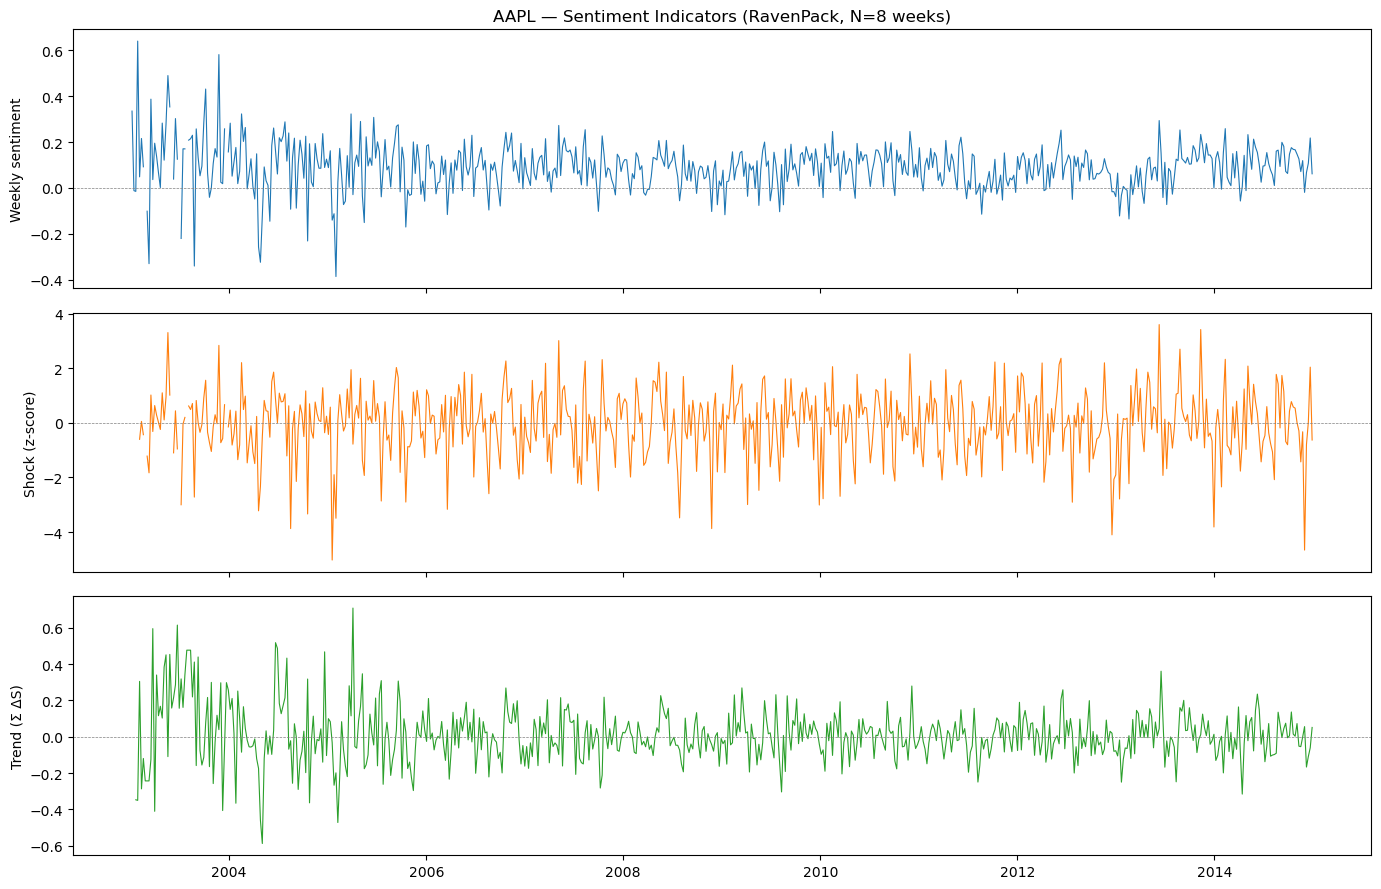

In [39]:
import matplotlib.pyplot as plt

if rsi_features["sentiment_score"].notna().any():
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(rsi_features["week_start"], rsi_features["sentiment_score"], lw=0.8)
    axes[0].axhline(0, color="grey", lw=0.5, ls="--")
    axes[0].set_ylabel("Weekly sentiment")
    axes[0].set_title(f"{TICKER} — Sentiment Indicators (RavenPack, N={N_WEEKS} weeks)")

    axes[1].plot(rsi_features["week_start"], rsi_features["shock"], lw=0.8, color="tab:orange")
    axes[1].axhline(0, color="grey", lw=0.5, ls="--")
    axes[1].set_ylabel("Shock (z-score)")

    axes[2].plot(rsi_features["week_start"], rsi_features["trend"], lw=0.8, color="tab:green")
    axes[2].axhline(0, color="grey", lw=0.5, ls="--")
    axes[2].set_ylabel("Trend (Σ ΔS)")

    fig.tight_layout()
    plt.show()
else:
    print("No sentiment data to plot.")

## Step 8 — Save Outputs

In [40]:
articles.to_parquet(ARTICLES_PATH, index=False)
daily.to_csv(DAILY_PATH, index=False)
weekly_agg.to_parquet(WEEKLY_PATH, index=False)
rsi_features.to_parquet(RSI_PATH, index=False)
# crsp_daily already saved in Step 2.5

summary_dict = {
    "created_at":                    datetime.now(timezone.utc).isoformat(),
    "ticker":                        summary.ticker,
    "rp_entity_id":                  rp_entity_id,
    "sentiment_source":              "ravenpack_dj",
    "market_source":                 "crsp",
    "start_date":                    summary.start_date,
    "end_date":                      summary.end_date,
    "total_articles":                summary.total_articles,
    "calendar_days_with_news":       summary.calendar_days_with_news,
    "calendar_days_in_range":        summary.calendar_days_in_range,
    "avg_articles_per_calendar_day": round(summary.avg_articles_per_calendar_day, 4),
    "avg_articles_per_week":         round(summary.avg_articles_per_week, 4),
    "weeks_in_range":                summary.weeks_in_range,
    "weeks_with_zero_articles":      summary.weeks_with_zero_articles,
    "passes_paper_weekly_threshold": summary.passes_paper_weekly_threshold,
    "articles_with_sentiment":       int(articles["sentiment_score"].notna().sum()),
    "articles_with_crsp_price":      int(articles["close"].notna().sum()),
    "crsp_trading_days":             int(crsp_daily["date"].nunique()),
    "weekly_ret_non_null":           int(rsi_features["weekly_ret"].notna().sum()),
    "rsi_non_null_weeks":            int(rsi_features[["shock", "trend"]].dropna().shape[0]),
    "n_weeks_lookback":              N_WEEKS,
    "refinitiv_text_fetched":        HAVE_REFINITIV and RF_TEXT_PATH.exists(),
    "outputs": {
        "articles":       str(ARTICLES_PATH.relative_to(PROJECT_ROOT)),
        "daily_csv":      str(DAILY_PATH.relative_to(PROJECT_ROOT)),
        "weekly":         str(WEEKLY_PATH.relative_to(PROJECT_ROOT)),
        "rsi":            str(RSI_PATH.relative_to(PROJECT_ROOT)),
        "crsp_daily":     str(CRSP_PATH.relative_to(PROJECT_ROOT)),
        "rp_checkpoint":  str(RP_CHECKPOINT_PATH.relative_to(PROJECT_ROOT)),
    },
}
if HAVE_REFINITIV and RF_TEXT_PATH.exists():
    summary_dict["outputs"]["rf_article_text"] = str(RF_TEXT_PATH.relative_to(PROJECT_ROOT))

SUMMARY_PATH.write_text(json.dumps(summary_dict, indent=2) + "\n", encoding="utf-8")

print(f"articles parquet → {ARTICLES_PATH.name}  ({len(articles):,} rows × {articles.shape[1]} cols)")
print(f"daily CSV        → {DAILY_PATH.name}")
print(f"weekly parquet   → {WEEKLY_PATH.name}  ({len(weekly_agg):,} rows)")
print(f"RSI parquet      → {RSI_PATH.name}  ({len(rsi_features):,} rows)")
print(f"CRSP parquet     → {CRSP_PATH.name}  ({len(crsp_daily):,} rows)")
print(f"summary JSON     → {SUMMARY_PATH.name}")
print()
print("Article-level columns:", articles.columns.tolist())
print()
print("Load in another notebook:")
print(f"  articles = pd.read_parquet(PROJECT_ROOT / 'data/raw/news/ravenpack/{slug}_articles_2003_2014.parquet')")
print(f"  rsi      = pd.read_parquet(PROJECT_ROOT / 'data/raw/news/ravenpack/{slug}_rsi_features_2003_2014.parquet')")

articles parquet → aapl_articles_2003_2014.parquet  (311,041 rows × 23 cols)
daily CSV        → aapl_daily_counts_2003_2014.csv
weekly parquet   → aapl_weekly_sentiment_2003_2014.parquet  (626 rows)
RSI parquet      → aapl_rsi_features_2003_2014.parquet  (626 rows)
CRSP parquet     → aapl_crsp_daily_2003_2014.parquet  (3,021 rows)
summary JSON     → aapl_coverage_summary.json

Article-level columns: ['ticker', 'source', 'article_time', 'article_date', 'week_start', 'headline', 'event_text', 'story_id', 'source_code', 'relevance_score', 'event_sentiment_score', 'sentiment_score', 'topic', 'group', 'type', 'news_type', 'articles_that_day', 'close', 'high', 'low', 'volume', 'daily_ret', 'shares_outstanding']

Load in another notebook:
  articles = pd.read_parquet(PROJECT_ROOT / 'data/raw/news/ravenpack/aapl_articles_2003_2014.parquet')
  rsi      = pd.read_parquet(PROJECT_ROOT / 'data/raw/news/ravenpack/aapl_rsi_features_2003_2014.parquet')


In [41]:
# Close WRDS connection
try:
    db.close()
    print("WRDS connection closed.")
except Exception as exc:
    print(f"WRDS close (safe to ignore): {exc}")

# Close Refinitiv session if it was opened
if HAVE_REFINITIV:
    try:
        ld.close_session()
        print("Refinitiv session closed.")
    except Exception as exc:
        print(f"Refinitiv close (safe to ignore): {exc}")

WRDS connection closed.
